In [14]:
!pip install bertopic sentence-transformers umap-learn hdbscan scikit-learn gensim PySastrawi octis seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from bertopic import BERTopic
from bertopic.representation import MaximalMarginalRelevance
from bertopic.vectorizers import ClassTfidfTransformer
from sentence_transformers import SentenceTransformer
import umap
from hdbscan import HDBSCAN
from sklearn.cluster import Birch, KMeans
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                              silhouette_samples)
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import gensim.corpora as corpora
from gensim.models.coherencemodel import CoherenceModel

from octis.evaluation_metrics.coherence_metrics import Coherence
from octis.evaluation_metrics.diversity_metrics import TopicDiversity

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from collections import Counter

plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_columns', None)

print("✓ Semua library berhasil diimport!")

✓ Semua library berhasil diimport!



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
df_with_stem = pd.read_csv(
    r'C:\Users\Admin\Downloads\data_clean_with_stemming (3).csv'
)
docs_stem = df_with_stem['clean_text'].dropna().tolist()

print(f"✓ Data loaded   : {len(docs_stem):,} dokumen")
print(f"✓ Shape         : {df_with_stem.shape}")
print(f"\n📝 Contoh dokumen:")
for i, d in enumerate(docs_stem[:3], 1):
    print(f"   {i}. {d[:100]}")

✓ Data loaded   : 1,699 dokumen
✓ Shape         : (1699, 1)

📝 Contoh dokumen:
   1. mau masuk beranda selalu loading
   2. aplikasi rumah sakit baik
   3. aplikasi lengkap fitur andal informatif


In [16]:
print("🔄 Loading IndoBERT embedding model...")
embedding_model = SentenceTransformer(
    "paraphrase-multilingual-MiniLM-L12-v2"
)
print("✓ Model loaded")

print("\n🔄 Generating embeddings...")
embeddings_stem = embedding_model.encode(
    docs_stem,
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True
)

np.save("embeddings_with_stemming.npy", embeddings_stem)
print(f"\n✓ Embeddings shape : {embeddings_stem.shape}")
print(f"✓ Disimpan ke      : embeddings_with_stemming.npy")

🔄 Loading IndoBERT embedding model...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1252.89it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Model loaded

🔄 Generating embeddings...


Batches: 100%|██████████| 54/54 [00:14<00:00,  3.68it/s]


✓ Embeddings shape : (1699, 384)
✓ Disimpan ke      : embeddings_with_stemming.npy


In [17]:
print("🔄 Running UMAP...")

umap_model_stem = umap.UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.1,
    metric="cosine",
    random_state=42,
    transform_seed=42
)

umap_embeddings_stem = umap_model_stem.fit_transform(embeddings_stem)
np.save("umap_embeddings_with_stemming.npy", umap_embeddings_stem)

print(f"✓ UMAP output shape : {umap_embeddings_stem.shape}")
print(f"✓ Disimpan ke       : umap_embeddings_with_stemming.npy")

🔄 Running UMAP...
✓ UMAP output shape : (1699, 5)
✓ Disimpan ke       : umap_embeddings_with_stemming.npy


ANALISIS SILHOUETTE & DBI — BIRCH & KMeans (WITH STEMMING)

      k   Sil-KMeans   DBI-KMeans    Sil-BIRCH    DBI-BIRCH
   ──────────────────────────────────────────────────────
      2       0.5873       0.5769       0.5629       0.5714
      3       0.5707       0.6233       0.5696       0.6222
      4       0.5276       0.7132       0.4937       0.8321
      5       0.4149       0.8858       0.3670       1.0320
      6       0.3793       1.0390       0.3897       0.9067
      7       0.3931       0.8878       0.3736       1.0046
      8       0.3874       0.9073       0.3289       1.0964
      9       0.3698       1.0044       0.3181       1.0701
     10       0.3617       1.0186       0.2855       1.1599
     11       0.3418       1.0627       0.2987       1.0826
     12       0.3455       1.0593       0.2882       1.0508
     13       0.3517       1.0619       0.2971       1.0269
     14       0.3455       1.0611       0.2969       1.0412
     15       0.3509       1.0205       0.

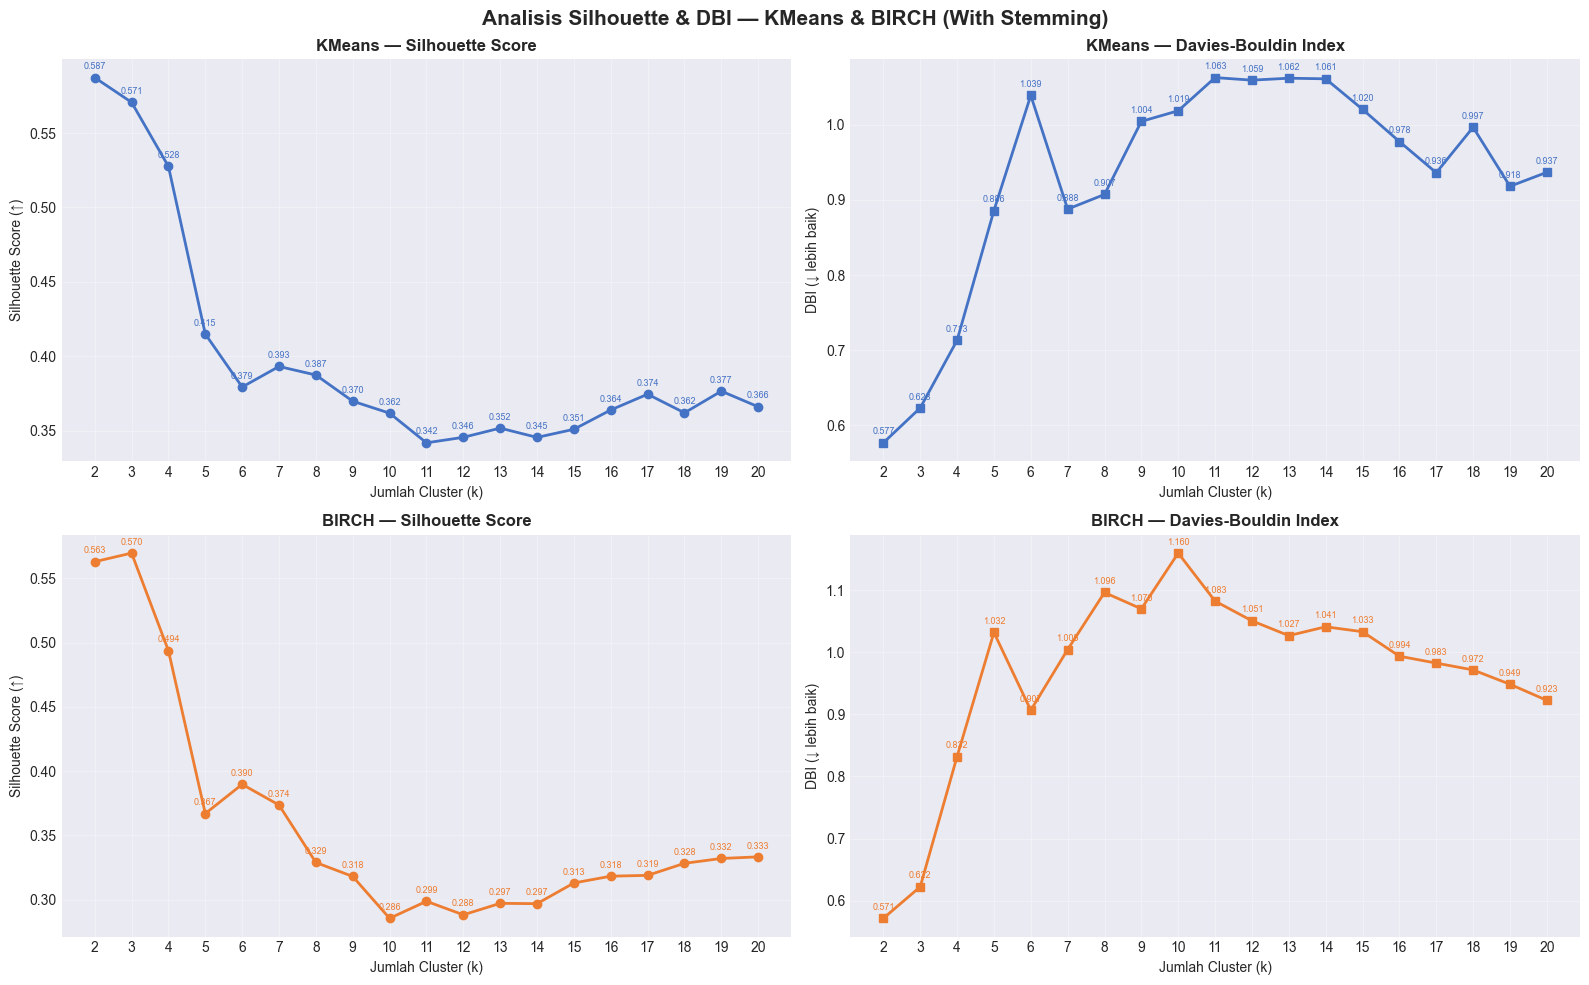

✓ Disimpan: k_analysis_stem.png

🔄 Menghitung silhouette & DBI per cluster...
  k= 2 | KMeans sil=0.5873 dbi=0.5769 | BIRCH sil=0.5629 dbi=0.5714
  k= 3 | KMeans sil=0.5707 dbi=0.6233 | BIRCH sil=0.5696 dbi=0.6222
  k= 4 | KMeans sil=0.5276 dbi=0.7132 | BIRCH sil=0.4937 dbi=0.8321
  k= 5 | KMeans sil=0.4149 dbi=0.8858 | BIRCH sil=0.3670 dbi=1.0320
  k= 6 | KMeans sil=0.3793 dbi=1.0390 | BIRCH sil=0.3897 dbi=0.9067
  k= 7 | KMeans sil=0.3931 dbi=0.8878 | BIRCH sil=0.3736 dbi=1.0046


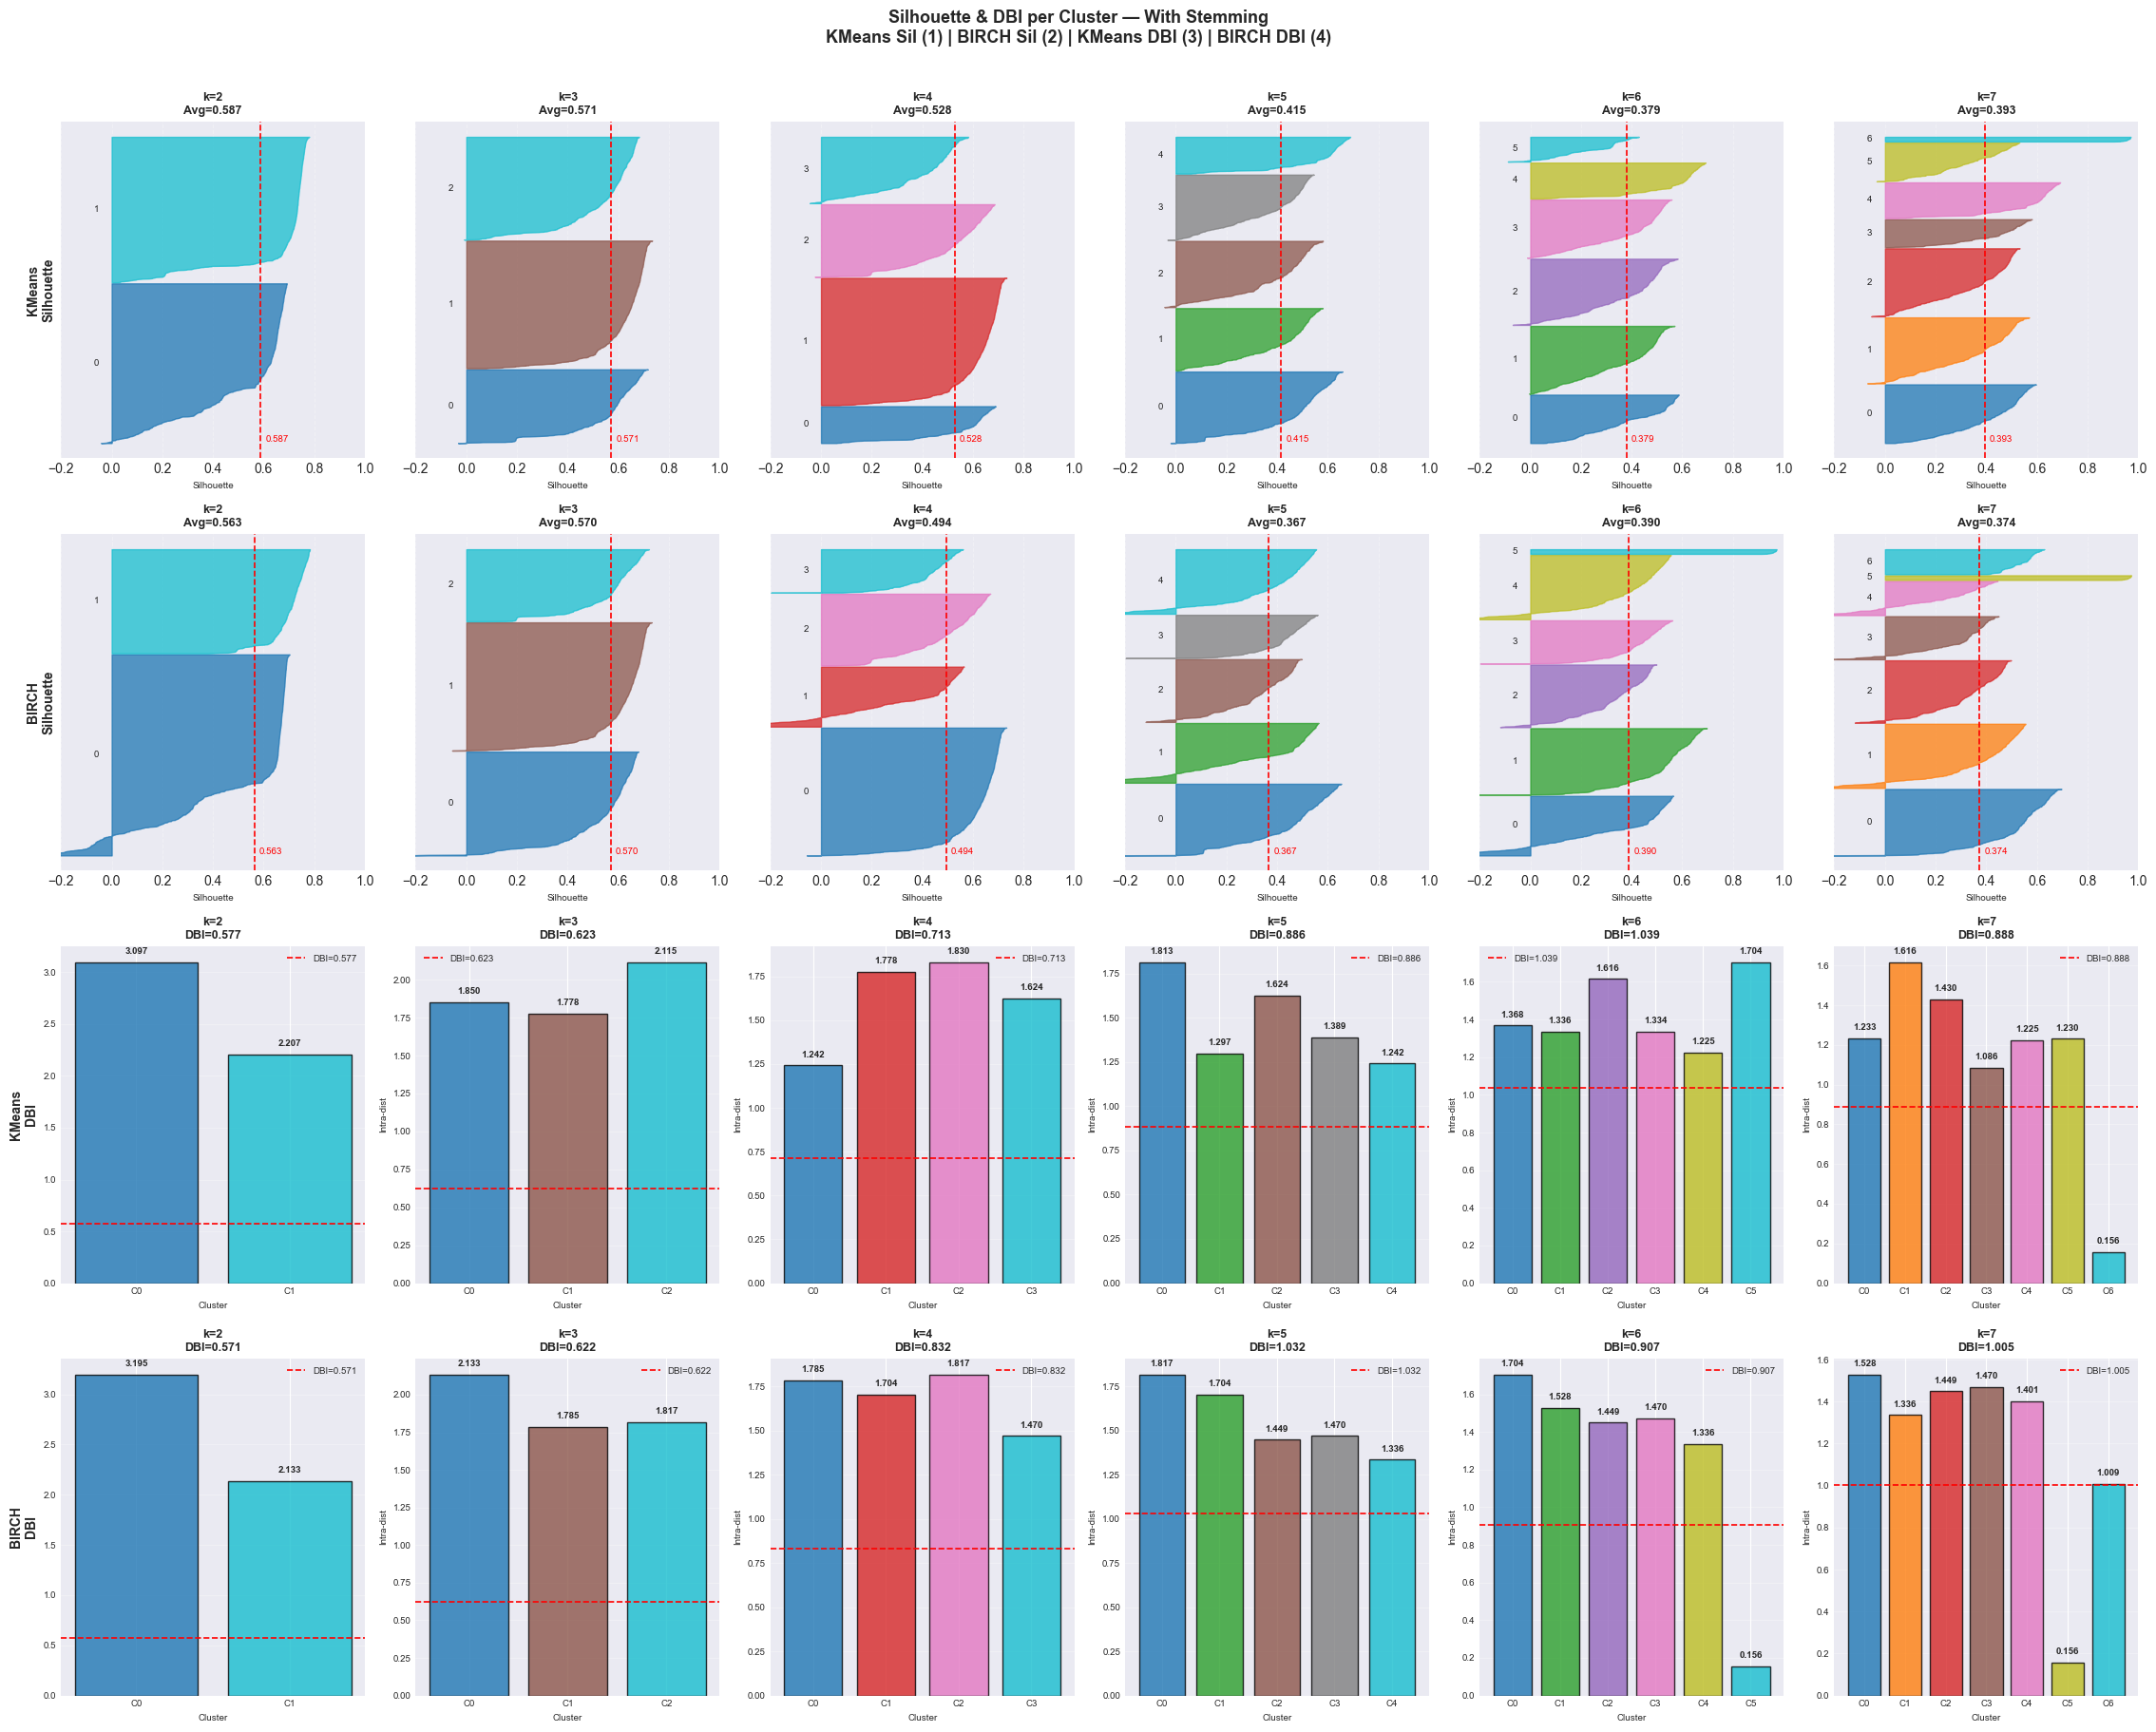

✓ Disimpan: silhouette_dbi_stem.png


In [5]:
print("="*70)
print("ANALISIS SILHOUETTE & DBI — BIRCH & KMeans (WITH STEMMING)")
print("="*70)

k_range      = range(2, 21)
sil_birch_s  = []
dbi_birch_s  = []
sil_kmeans_s = []
dbi_kmeans_s = []

print(f"\n   {'k':>4} {'Sil-KMeans':>12} {'DBI-KMeans':>12} "
      f"{'Sil-BIRCH':>12} {'DBI-BIRCH':>12}")
print("   " + "─"*54)

for k in k_range:
    km  = KMeans(n_clusters=k, n_init=10, random_state=42)
    lkm = km.fit_predict(umap_embeddings_stem)
    skm = silhouette_score(umap_embeddings_stem, lkm)
    dkm = davies_bouldin_score(umap_embeddings_stem, lkm)
    sil_kmeans_s.append(skm)
    dbi_kmeans_s.append(dkm)

    br  = Birch(threshold=0.5, n_clusters=k, branching_factor=50)
    lbr = br.fit_predict(umap_embeddings_stem)
    sbr = silhouette_score(umap_embeddings_stem, lbr)
    dbr = davies_bouldin_score(umap_embeddings_stem, lbr)
    sil_birch_s.append(sbr)
    dbi_birch_s.append(dbr)

    print(f"   {k:>4} {skm:>12.4f} {dkm:>12.4f} "
          f"{sbr:>12.4f} {dbr:>12.4f}")

k_list = list(k_range)

# ── Line Chart ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(
    'Analisis Silhouette & DBI — KMeans & BIRCH (With Stemming)',
    fontsize=15, fontweight='bold'
)

plot_configs = [
    (axes[0,0], sil_kmeans_s, '#4472C4',
     'KMeans — Silhouette Score',     'Silhouette Score (↑)'),
    (axes[0,1], dbi_kmeans_s, '#4472C4',
     'KMeans — Davies-Bouldin Index', 'DBI (↓ lebih baik)'),
    (axes[1,0], sil_birch_s,  '#ED7D31',
     'BIRCH — Silhouette Score',      'Silhouette Score (↑)'),
    (axes[1,1], dbi_birch_s,  '#ED7D31',
     'BIRCH — Davies-Bouldin Index',  'DBI (↓ lebih baik)'),
]

for ax, data, color, title, ylabel in plot_configs:
    marker = 'o' if 'Silhouette' in title else 's'
    ax.plot(k_list, data, f'{marker}-', color=color,
            linewidth=2, markersize=6)
    for k, v in zip(k_list, data):
        ax.annotate(f'{v:.3f}', (k, v),
                    textcoords="offset points",
                    xytext=(0, 6), ha='center',
                    fontsize=6.5, color=color)
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xlabel('Jumlah Cluster (k)')
    ax.set_ylabel(ylabel)
    ax.set_xticks(k_list)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('k_analysis_stem.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Disimpan: k_analysis_stem.png")

# ── Silhouette Plot per Cluster ───────────────────────────────────
k_values = list(range(2, 8))

def plot_silhouette(ax, embeddings, labels, k, avg_score):
    n_clusters      = len(set(labels))
    silhouette_vals = silhouette_samples(embeddings, labels)
    y_lower         = 10
    palette         = cm.get_cmap('tab10', n_clusters)
    for i in range(n_clusters):
        cluster_vals = np.sort(silhouette_vals[labels == i])
        size_i       = cluster_vals.shape[0]
        y_upper      = y_lower + size_i
        color        = palette(i / n_clusters)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0,
                         cluster_vals, facecolor=color,
                         edgecolor=color, alpha=0.75)
        ax.text(-0.05, y_lower + 0.5*size_i, str(i),
                fontsize=7, va='center', ha='right')
        y_lower = y_upper + 5
    ax.axvline(avg_score, color='red', linestyle='--', linewidth=1.2)
    ax.text(avg_score+0.02, 5, f'{avg_score:.3f}',
            color='red', fontsize=7, va='bottom')
    ax.set_title(f"k={k}\nAvg={avg_score:.3f}",
                 fontsize=9, fontweight='bold')
    ax.set_xlim([-0.2, 1.0])
    ax.set_xlabel('Silhouette', fontsize=7)
    ax.set_yticks([])
    ax.grid(axis='x', alpha=0.3, linestyle='--')


def plot_dbi_bar(ax, embeddings, labels, k, dbi_score):
    from sklearn.metrics import pairwise_distances
    unique_labels = sorted(set(labels))
    n_clusters    = len(unique_labels)
    palette       = cm.get_cmap('tab10', n_clusters)
    intra_dists   = []
    for label in unique_labels:
        pts = embeddings[labels == label]
        if len(pts) > 1:
            dists = pairwise_distances(pts, metric='euclidean')
            intra = dists[np.triu_indices_from(dists, k=1)].mean()
        else:
            intra = 0.0
        intra_dists.append(intra)
    colors = [palette(i / n_clusters) for i in range(n_clusters)]
    bars   = ax.bar([f'C{i}' for i in unique_labels],
                    intra_dists, color=colors,
                    edgecolor='black', alpha=0.8)
    for bar, val in zip(bars, intra_dists):
        ax.text(bar.get_x() + bar.get_width()/2.,
                bar.get_height() + max(intra_dists)*0.02,
                f'{val:.3f}', ha='center', va='bottom',
                fontsize=7, fontweight='bold')
    ax.axhline(dbi_score, color='red', linestyle='--',
               linewidth=1.2, label=f'DBI={dbi_score:.3f}')
    ax.legend(fontsize=7)
    ax.set_title(f"k={k}\nDBI={dbi_score:.3f}",
                 fontsize=9, fontweight='bold')
    ax.set_xlabel('Cluster', fontsize=7)
    ax.set_ylabel('Intra-dist', fontsize=7)
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(labelsize=7)


n_cols = len(k_values)
fig, axes = plt.subplots(4, n_cols, figsize=(n_cols*3.8, 18))
fig.suptitle(
    "Silhouette & DBI per Cluster — With Stemming\n"
    "KMeans Sil (1) | BIRCH Sil (2) | KMeans DBI (3) | BIRCH DBI (4)",
    fontsize=13, fontweight='bold', y=1.01
)

print("\n🔄 Menghitung silhouette & DBI per cluster...")
for col, k in enumerate(k_values):
    km        = KMeans(n_clusters=k, n_init=10, random_state=42)
    km_labels = km.fit_predict(umap_embeddings_stem)
    km_sil    = silhouette_score(umap_embeddings_stem, km_labels)
    km_dbi    = davies_bouldin_score(umap_embeddings_stem, km_labels)

    br        = Birch(threshold=0.5, n_clusters=k, branching_factor=50)
    br_labels = br.fit_predict(umap_embeddings_stem)
    br_sil    = silhouette_score(umap_embeddings_stem, br_labels)
    br_dbi    = davies_bouldin_score(umap_embeddings_stem, br_labels)

    plot_silhouette(axes[0, col], umap_embeddings_stem,
                    km_labels, k, km_sil)
    plot_silhouette(axes[1, col], umap_embeddings_stem,
                    br_labels, k, br_sil)
    plot_dbi_bar(axes[2, col], umap_embeddings_stem,
                 km_labels, k, km_dbi)
    plot_dbi_bar(axes[3, col], umap_embeddings_stem,
                 br_labels, k, br_dbi)
    print(f"  k={k:2d} | KMeans sil={km_sil:.4f} dbi={km_dbi:.4f} "
          f"| BIRCH sil={br_sil:.4f} dbi={br_dbi:.4f}")

row_labels = ["KMeans\nSilhouette", "BIRCH\nSilhouette",
              "KMeans\nDBI", "BIRCH\nDBI"]
for row, label in enumerate(row_labels):
    axes[row, 0].set_ylabel(label, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('silhouette_dbi_stem.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("✓ Disimpan: silhouette_dbi_stem.png")

In [18]:
# ── Isi setelah lihat visualisasi ────────────────────────────────
k_opt_kmeans_s = 3  # ← ganti sesuai pilihanmu
k_opt_birch_s  = 3   # ← ganti sesuai pilihanmu

print(f"{'='*50}")
print(f"✅ K Optimal yang Dipilih (With Stemming)")
print(f"{'='*50}")
print(f"   KMeans → k = {k_opt_kmeans_s}  "
      f"(Sil: {sil_kmeans_s[k_opt_kmeans_s-2]:.4f}, "
      f"DBI: {dbi_kmeans_s[k_opt_kmeans_s-2]:.4f})")
print(f"   BIRCH  → k = {k_opt_birch_s}  "
      f"(Sil: {sil_birch_s[k_opt_birch_s-2]:.4f}, "
      f"DBI: {dbi_birch_s[k_opt_birch_s-2]:.4f})")

✅ K Optimal yang Dipilih (With Stemming)
   KMeans → k = 3  (Sil: 0.5707, DBI: 0.6233)
   BIRCH  → k = 3  (Sil: 0.5696, DBI: 0.6222)


In [ ]:
print("="*70)
print("INISIALISASI CLUSTERING MODELS & VECTORIZER (WITH STEMMING)")
print("="*70)

hdbscan_model_s = HDBSCAN(
    min_cluster_size=20,
    min_samples=3,
    metric="euclidean",
    cluster_selection_method="leaf",
    cluster_selection_epsilon=0.4,
    prediction_data=True
)

birch_model_s  = Birch(
    n_clusters=k_opt_birch_s,
    threshold=0.5,
    branching_factor=50
)

kmeans_model_s = KMeans(
    n_clusters=k_opt_kmeans_s,
    n_init=10,
    random_state=42
)

# ── Stopwords ─────────────────────────────────────────────────────
factory_sw    = StopWordRemoverFactory()
stopwords_id  = factory_sw.get_stop_words()

additional_sw_stem = [
    'yg','nya','dgn','utk','ttg','yaa','aja','nih','sih','deh',
    'dong','kok','lah','hehe','wkwk','haha','u','x','tp','sy',
    'dn','ok','mysiloam','siloam','rs','my','the','so','this',
    'that','and','or','but','really','very','all','is','di',
    'ke','dan','semoga','selalu','sukses','terus','semakin',
    'terima','kasih','terimakasih','trimakasih',
    'aplikasi','apk','app',
]
all_stopwords_stem = set(stopwords_id + additional_sw_stem)

vectorizer = CountVectorizer(
    ngram_range=(1, 2),
    stop_words=list(all_stopwords_stem),
    min_df=2,
    max_df=0.95
)


ctfidf_model_s         = ClassTfidfTransformer(
    reduce_frequent_words=True
)
representation_model_s = MaximalMarginalRelevance(
    diversity=0.6, top_n_words=10
)

print(f"✓ HDBSCAN  : min_cluster_size=20, min_samples=3")
print(f"✓ BIRCH    : n_clusters={k_opt_birch_s}")
print(f"✓ KMeans   : n_clusters={k_opt_kmeans_s}")
print(f"✓ Stopwords: {len(all_stopwords_stem)} kata")

INISIALISASI CLUSTERING MODELS & VECTORIZER (WITH STEMMING)
✓ HDBSCAN  : min_cluster_size=20, min_samples=3
✓ BIRCH    : n_clusters=3
✓ KMeans   : n_clusters=3
✓ Stopwords: 850 kata


In [20]:
print("="*70)
print("RUNNING BERTOPIC — WITH STEMMING")
print("="*70)

bertopic_models_stem  = {}
bertopic_results_stem = {}

cluster_configs_stem = {
    "HDBSCAN": (hdbscan_model_s, vectorizer_density_s,
                representation_model_s, True),
    "BIRCH"  : (birch_model_s,   vectorizer_density_s,
                representation_model_s, False),
    "KMEANS" : (kmeans_model_s,  vectorizer_kmeans_s,
                None,            False),
}

for name, (cluster_model, vectorizer, repr_model, calc_prob) \
        in cluster_configs_stem.items():

    print(f"\n{'─'*70}")
    print(f"📌 Running BERTopic + {name} (With Stemming)")
    print(f"{'─'*70}")

    topic_model = BERTopic(
        embedding_model=embedding_model,
        umap_model=umap_model_stem,
        hdbscan_model=cluster_model,
        vectorizer_model=vectorizer,
        ctfidf_model=ctfidf_model_s,
        representation_model=repr_model,
        calculate_probabilities=calc_prob,
        verbose=True
    )

    topics, probs = topic_model.fit_transform(
        docs_stem, embeddings=embeddings_stem
    )

    info       = topic_model.get_topic_info()
    is_hdbscan = (name == "HDBSCAN")
    n_topics   = len(info[info.Topic != -1]) \
                 if is_hdbscan else len(info)
    noise_count = sum(t == -1 for t in topics) if is_hdbscan else 0
    noise_ratio = noise_count/len(topics)*100 if is_hdbscan else 0.0

    print(f"\n  ✓ Selesai!")
    print(f"  🧩 Jumlah topik  : {n_topics}")
    print(f"  ⚠️  Noise docs    : {noise_count} ({noise_ratio:.1f}%)")
    print(f"\n  {'ID':>6} {'N Dok':>7}   Top Words")
    print(f"  {'─'*65}")

    for _, row in info.iterrows():
        if is_hdbscan and row['Topic'] == -1:
            continue
        words = topic_model.get_topic(row['Topic'])
        top   = ", ".join([w for w, _ in words[:7]]) \
                if words else "-"
        print(f"  #{row['Topic']:<5}  {row['Count']:>7,}   {top}")

    bertopic_models_stem[name]  = topic_model
    bertopic_results_stem[name] = {
        "topics"     : topics,
        "probs"      : probs if is_hdbscan else None,
        "n_topics"   : n_topics,
        "noise_count": noise_count,
        "noise_ratio": noise_ratio,
        "topic_info" : info,
    }

print(f"\n{'='*70}")
print("✓ Semua model selesai!")
for name, res in bertopic_results_stem.items():
    print(f"  {name:<10}: {res['n_topics']} topik, "
          f"noise: {res['noise_count']} ({res['noise_ratio']:.1f}%)")

2026-04-02 12:57:14,341 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


RUNNING BERTOPIC — WITH STEMMING

──────────────────────────────────────────────────────────────────────
📌 Running BERTopic + HDBSCAN (With Stemming)
──────────────────────────────────────────────────────────────────────


2026-04-02 12:57:20,289 - BERTopic - Dimensionality - Completed ✓
2026-04-02 12:57:20,289 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-02 12:57:20,469 - BERTopic - Cluster - Completed ✓
2026-04-02 12:57:20,485 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-02 12:57:21,596 - BERTopic - Representation - Completed ✓
2026-04-02 12:57:21,693 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm



  ✓ Selesai!
  🧩 Jumlah topik  : 9
  ⚠️  Noise docs    : 88 (5.2%)

      ID   N Dok   Top Words
  ─────────────────────────────────────────────────────────────────
  #0          672   rumah sakit, jadwal, appointment, ramah, obat, asuransi, tunggu
  #1          326   error, data, hp, otp, booking, pcr, server
  #2          258   mudah cepat, bagus, bantu praktis, bintang, respon cepat, pelayananya, manfaat
  #3          179   ramah, cepat bagus, fasilitas, puas, profesional, buruk, bersih
  #4           68   indonesia, alhamdulillah bantu, masyarakat, programmer, god, administrasi security, usia
  #5           31   mudah obat, kemarin, cepat proses, tugas farmasi, dg dr, selesai janji, gratis bantu
  #6           27   bantu bantu, manfaat bantu, informatif bantu, rapih, mudah an, informasi ubah, efisien bantu
  #7           27   daftar vaksin, antigen, daftar tutup, ortu, efektif efisien, download ad, payment
  #8           23   daftar mudah, proses daftar, bantu proses, daftar bantu

2026-04-02 12:57:26,719 - BERTopic - Dimensionality - Completed ✓
2026-04-02 12:57:26,719 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-02 12:57:26,986 - BERTopic - Cluster - Completed ✓
2026-04-02 12:57:26,997 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-02 12:57:27,337 - BERTopic - Representation - Completed ✓
2026-04-02 12:57:27,378 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm



  ✓ Selesai!
  🧩 Jumlah topik  : 3
  ⚠️  Noise docs    : 0 (0.0%)

      ID   N Dok   Top Words
  ─────────────────────────────────────────────────────────────────
  #0          716   rumah sakit, jadwal, appointment, asuransi, mudah pasien, keluarga, online
  #1          580   profesional, fasilitas, bintang, pelayananya, ramah bagus, ramah bantu, simpel
  #2          403   data, update, download, server, daftar online, gagal, self check

──────────────────────────────────────────────────────────────────────
📌 Running BERTopic + KMEANS (With Stemming)
──────────────────────────────────────────────────────────────────────


2026-04-02 12:57:32,329 - BERTopic - Dimensionality - Completed ✓
2026-04-02 12:57:32,329 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-02 12:57:32,460 - BERTopic - Cluster - Completed ✓
2026-04-02 12:57:32,465 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-02 12:57:32,542 - BERTopic - Representation - Completed ✓



  ✓ Selesai!
  🧩 Jumlah topik  : 3
  ⚠️  Noise docs    : 0 (0.0%)

      ID   N Dok   Top Words
  ─────────────────────────────────────────────────────────────────
  #0          713   dokter, sakit, rumah, rumah sakit, pasien, obat, antri
  #1          574   bagus, cepat, bantu, mudah, muas, ramah, bantu bantu
  #2          412   daftar, vaksin, data, error, mudah, update, booking

✓ Semua model selesai!
  HDBSCAN   : 9 topik, noise: 88 (5.2%)
  BIRCH     : 3 topik, noise: 0 (0.0%)
  KMEANS    : 3 topik, noise: 0 (0.0%)


In [21]:
print("="*70)
print("PERSIAPAN EVALUASI — WITH STEMMING")
print("="*70)

# Corpus
texts_tokenized_stem = [str(doc).lower().split()
                        for doc in docs_stem]
dictionary_stem      = corpora.Dictionary(texts_tokenized_stem)
dictionary_stem.filter_extremes(no_below=3, no_above=0.90)

print(f"✓ Dictionary: {len(dictionary_stem):,} kata")

# OCTIS metrics
npmi_metric_stem      = Coherence(
    texts=texts_tokenized_stem,
    topk=10,
    measure='c_npmi'
)
diversity_metric_stem = TopicDiversity(topk=10)

print("✓ OCTIS NPMI metric      → npmi_metric_stem")
print("✓ OCTIS Diversity metric → diversity_metric_stem")

# Konversi BERTopic → OCTIS
def bertopic_to_octis(topic_model, top_n=10):
    info   = topic_model.get_topic_info()
    topics = []
    for _, row in info.iterrows():
        if row["Topic"] == -1: continue
        words = topic_model.get_topic(row["Topic"])
        if words:
            topics.append([w for w, _ in words[:top_n]])
    return {"topics": topics}

# Fungsi C_V & U_MASS
def compute_coherence_gensim_stem(topic_model,
                                   metric="c_v", top_n=10):
    info         = topic_model.get_topic_info()
    topics_words = []
    for _, row in info.iterrows():
        if str(row["Topic"]) == '-1': continue
        words = topic_model.get_topic(row["Topic"])
        tw    = [w for w, _ in (words or [])[:top_n*3]
                 if w in dictionary_stem.token2id][:top_n]
        if len(tw) >= 2:
            topics_words.append(tw)
    if len(topics_words) < 2: return 0.0
    try:
        cm = CoherenceModel(
            topics=topics_words,
            texts=texts_tokenized_stem,
            dictionary=dictionary_stem,
            coherence=metric, topn=top_n
        )
        return round(cm.get_coherence(), 4)
    except Exception as e:
        print(f"    ⚠️  {metric} error: {e}")
        return 0.0

# Fungsi Perplexity
def compute_perplexity_stem(name):
    try:
        probs = bertopic_results_stem[name].get('probs', None)
        if probs is None: return None
        topics    = bertopic_results_stem[name]['topics']
        valid_idx = [i for i, t in enumerate(topics) if t != -1]
        if len(valid_idx) == 0: return None
        pv       = np.array(probs)[valid_idx]
        if pv.ndim == 1: pv = pv.reshape(-1, 1)
        row_sums = np.clip(np.sum(pv, axis=1), 1e-10, None)
        return round(
            float(np.exp(-1 * np.mean(np.log(row_sums)))), 4
        )
    except Exception as e:
        print(f"    ⚠️  Perplexity error: {e}")
        return None

# Fungsi Stability
def jaccard_similarity(set1, set2):
    s1 = set(set1); s2 = set(set2)
    return len(s1&s2)/len(s1|s2) if len(s1|s2) > 0 else 0.0

def compute_stability_stem(topic_model, n_runs=2, top_n=10,
                            cluster_model=None, vectorizer=None,
                            repr_model=None, calc_prob=False):
    all_run_topics = []
    base = []
    for _, row in topic_model.get_topic_info().iterrows():
        if row['Topic'] == -1: continue
        w = topic_model.get_topic(row['Topic'])
        if w: base.append([x for x, _ in w[:top_n]])
    all_run_topics.append(base)
    print(f"     Run 1/{n_runs} ✓ ({len(base)} topik)")

    for run in range(n_runs - 1):
        print(f"     Run {run+2}/{n_runs}...", end=" ")
        try:
            tm_temp = BERTopic(
                embedding_model=embedding_model,
                umap_model=umap_model_stem,
                hdbscan_model=cluster_model,
                vectorizer_model=vectorizer,
                ctfidf_model=ctfidf_model_s,
                representation_model=repr_model,
                calculate_probabilities=calc_prob,
                verbose=False
            )
            tm_temp.fit_transform(
                docs_stem, embeddings=embeddings_stem
            )
            run_t = []
            for _, row in tm_temp.get_topic_info().iterrows():
                if row['Topic'] == -1: continue
                w = tm_temp.get_topic(row['Topic'])
                if w: run_t.append([x for x, _ in w[:top_n]])
            all_run_topics.append(run_t)
            print(f"✓ ({len(run_t)} topik)")
        except Exception as e:
            print(f"⚠️  {e}"); continue

    jaccard_scores = []
    for i in range(len(all_run_topics)):
        for j in range(i+1, len(all_run_topics)):
            ta_l    = all_run_topics[i]
            tb_l    = all_run_topics[j]
            min_len = min(len(ta_l), len(tb_l))
            if min_len == 0: continue
            used = set(); run_j = []
            for ta in ta_l[:min_len]:
                bs, bk = 0, -1
                for k, tb in enumerate(tb_l[:min_len]):
                    if k in used: continue
                    s = jaccard_similarity(ta, tb)
                    if s > bs: bs, bk = s, k
                if bk >= 0:
                    used.add(bk); run_j.append(bs)
            if run_j: jaccard_scores.append(np.mean(run_j))

    return round(np.mean(jaccard_scores), 4) \
           if jaccard_scores else 0.0

# Konfigurasi stability
stability_cfg_stem = {
    "HDBSCAN": {"cluster_model": hdbscan_model_s,
                "vectorizer"   : vectorizer_density_s,
                "repr_model"   : representation_model_s,
                "calc_prob"    : True},
    "BIRCH"  : {"cluster_model": birch_model_s,
                "vectorizer"   : vectorizer_density_s,
                "repr_model"   : representation_model_s,
                "calc_prob"    : False},
    "KMEANS" : {"cluster_model": kmeans_model_s,
                "vectorizer"   : vectorizer_kmeans_s,
                "repr_model"   : None,
                "calc_prob"    : False},
}

print("✓ Semua fungsi evaluasi siap!")

PERSIAPAN EVALUASI — WITH STEMMING
✓ Dictionary: 761 kata
✓ OCTIS NPMI metric      → npmi_metric_stem
✓ OCTIS Diversity metric → diversity_metric_stem
✓ Semua fungsi evaluasi siap!


In [22]:
print("="*70)
print("EVALUASI TOPIC MODEL — WITH STEMMING (TANPA STABILITY)")
print("="*70)

eval_results_stem = {}

for name in ["HDBSCAN", "BIRCH", "KMEANS"]:
    print(f"\n{'─'*70}")
    print(f"📌 Evaluasi — {name} (With Stemming)")
    print(f"{'─'*70}")

    tm      = bertopic_models_stem[name]
    info    = tm.get_topic_info()
    n_topik = len(info[info['Topic'] != -1]) \
              if name == "HDBSCAN" else len(info)
    scores  = {}

    print(f"\n  📋 Jumlah topik: {n_topik}")
    print(f"  {'ID':>6} {'N Dok':>7}   Top Words")
    print(f"  {'─'*60}")
    for _, row in info.iterrows():
        if str(row['Topic']) == '-1': continue
        words = tm.get_topic(row['Topic'])
        top   = ", ".join([w for w, _ in words[:5]]) \
                if words else "-"
        print(f"  #{row['Topic']:<5}  {row['Count']:>7,}   {top}")

    octis_output = bertopic_to_octis(tm, top_n=10)

    # 1. C_V
    print(f"\n  🔄 [1/5] C_V")
    scores['c_v'] = compute_coherence_gensim_stem(tm, "c_v")
    print(f"         → {scores['c_v']:.4f}  "
          f"({'✅' if scores['c_v'] > 0.5 else '⚠️ '} ideal > 0.5)")

    # 2. U_MASS
    print(f"\n  🔄 [2/5] U_MASS")
    scores['u_mass'] = compute_coherence_gensim_stem(
        tm, "u_mass"
    )
    print(f"         → {scores['u_mass']:.4f}  "
          f"({'✅' if scores['u_mass'] > -5 else '⚠️ '} ideal > -5)")

    # 3. NPMI via OCTIS
    print(f"\n  🔄 [3/5] NPMI — OCTIS")
    try:
        scores['npmi'] = round(
            npmi_metric_stem.score(octis_output), 4
        )
        print(f"         → {scores['npmi']:.4f}  "
              f"({'✅' if scores['npmi'] > 0 else '⚠️ '} ideal > 0)")
    except Exception as e:
        print(f"         ⚠️  {e}"); scores['npmi'] = 0.0

    # 4. Diversity via OCTIS
    print(f"\n  🔄 [4/5] Topic Diversity — OCTIS")
    try:
        scores['diversity'] = round(
            diversity_metric_stem.score(octis_output), 4
        )
        print(f"         → {scores['diversity']:.4f}  "
              f"({'✅' if scores['diversity'] > 0.6 else '⚠️ '} ideal > 0.6)")
    except Exception as e:
        print(f"         ⚠️  {e}"); scores['diversity'] = 0.0

    # 5. Perplexity
    print(f"\n  🔄 [5/5] Perplexity")
    perp             = compute_perplexity_stem(name)
    scores['perplexity'] = perp
    if perp is not None:
        print(f"         → {perp:.4f}  (↓ makin baik)")
    else:
        print(f"         → N/A  (hanya HDBSCAN)")

    scores['stability']   = 0.0
    scores['n_topics']    = n_topik
    scores['noise_count'] = bertopic_results_stem[name]['noise_count']
    scores['noise_ratio'] = bertopic_results_stem[name]['noise_ratio']
    eval_results_stem[name] = scores

    perp_str = f"{perp:.4f}" if perp is not None else "N/A"
    print(f"\n  📊 {name}: C_V={scores['c_v']:.4f} | "
          f"U_MASS={scores['u_mass']:.4f} | "
          f"NPMI={scores['npmi']:.4f} | "
          f"Div={scores['diversity']:.4f} | "
          f"Perp={perp_str}")

print(f"\n✅ Evaluasi cepat selesai! → Lanjut Cell 13 (Stability)")

EVALUASI TOPIC MODEL — WITH STEMMING (TANPA STABILITY)

──────────────────────────────────────────────────────────────────────
📌 Evaluasi — HDBSCAN (With Stemming)
──────────────────────────────────────────────────────────────────────

  📋 Jumlah topik: 9
      ID   N Dok   Top Words
  ────────────────────────────────────────────────────────────
  #0          672   rumah sakit, jadwal, appointment, ramah, obat
  #1          326   error, data, hp, otp, booking
  #2          258   mudah cepat, bagus, bantu praktis, bintang, respon cepat
  #3          179   ramah, cepat bagus, fasilitas, puas, profesional
  #4           68   indonesia, alhamdulillah bantu, masyarakat, programmer, god
  #5           31   mudah obat, kemarin, cepat proses, tugas farmasi, dg dr
  #6           27   bantu bantu, manfaat bantu, informatif bantu, rapih, mudah an
  #7           27   daftar vaksin, antigen, daftar tutup, ortu, efektif efisien
  #8           23   daftar mudah, proses daftar, bantu proses, daftar ba

In [23]:
print("="*70)
print("TOPIC STABILITY — WITH STEMMING (n_runs=2)")
print("="*70)

for name in ["HDBSCAN", "BIRCH", "KMEANS"]:
    print(f"\n{'─'*50}")
    print(f"📌 {name}")
    cfg = stability_cfg_stem[name]

    stab = compute_stability_stem(
        topic_model   = bertopic_models_stem[name],
        n_runs        = 2,
        top_n         = 10,
        cluster_model = cfg['cluster_model'],
        vectorizer    = cfg['vectorizer'],
        repr_model    = cfg['repr_model'],
        calc_prob     = cfg['calc_prob']
    )

    eval_results_stem[name]['stability'] = stab
    print(f"  ✓ Stability: {stab:.4f}  "
          f"({'✅' if stab > 0.5 else '⚠️ '} ideal > 0.5)")

print(f"\n✅ Stability selesai! → Lanjut Cell 14")

TOPIC STABILITY — WITH STEMMING (n_runs=2)

──────────────────────────────────────────────────
📌 HDBSCAN
     Run 1/2 ✓ (9 topik)
     Run 2/2... ✓ (9 topik)
  ✓ Stability: 1.0000  (✅ ideal > 0.5)

──────────────────────────────────────────────────
📌 BIRCH
     Run 1/2 ✓ (3 topik)
     Run 2/2... ✓ (3 topik)
  ✓ Stability: 1.0000  (✅ ideal > 0.5)

──────────────────────────────────────────────────
📌 KMEANS
     Run 1/2 ✓ (3 topik)
     Run 2/2... ✓ (3 topik)
  ✓ Stability: 1.0000  (✅ ideal > 0.5)

✅ Stability selesai! → Lanjut Cell 14


TABEL PERBANDINGAN 3 MODEL — WITH STEMMING

Model       N Topik      C_V    U_MASS     NPMI  Diversity  Stability   Perplexity
────────────────────────────────────────────────────────────────────────────────
HDBSCAN           9   0.4108  -13.2922      nan     0.9889     1.0000       1.0340
BIRCH             3   0.2858  -14.5805  -0.4137     1.0000     1.0000          N/A
KMEANS            3   0.4113   -3.8012  -0.0200     0.9000     1.0000          N/A
────────────────────────────────────────────────────────────────────────────────
Ideal             ─     >0.5     >-5.0     >0.0       >0.6       >0.5        ↓ min

✓ Disimpan: evaluation_with_stemming.csv


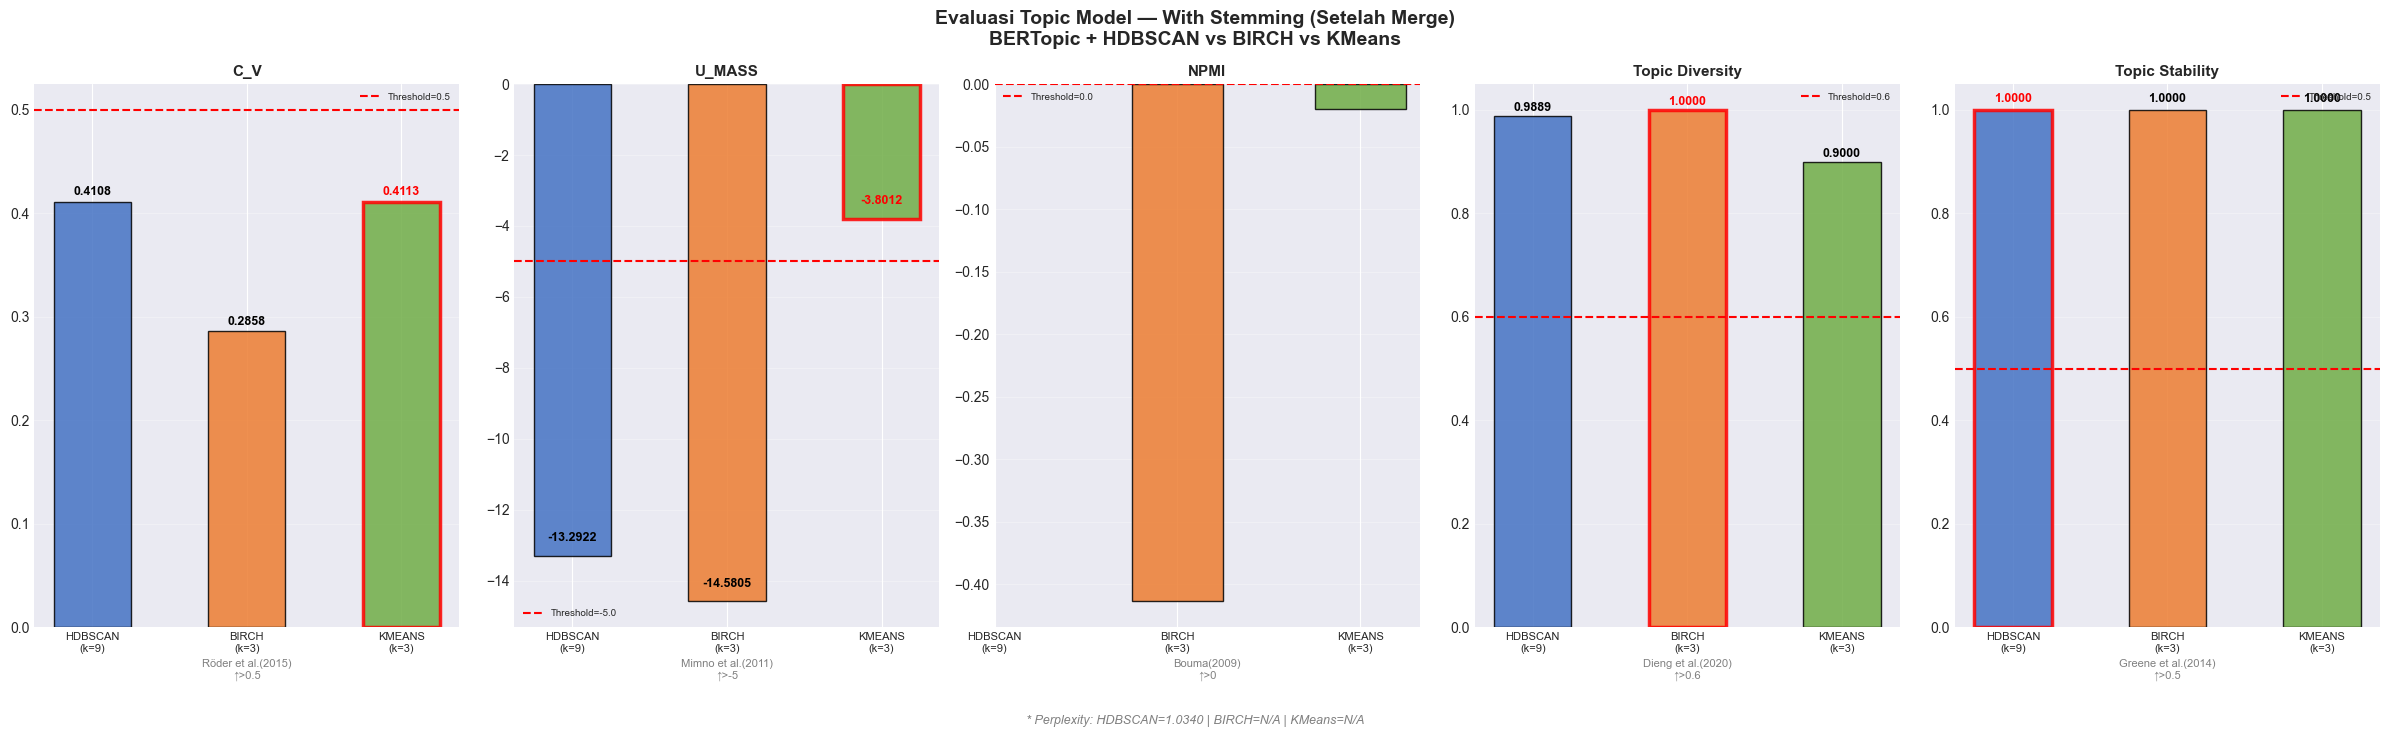

✓ Disimpan: evaluation_chart_with_stemming.png

🏆 REKOMENDASI MODEL TERBAIK — WITH STEMMING

  C_V terbaik   → KMEANS
  U_MASS terbaik→ KMEANS
  NPMI terbaik  → HDBSCAN
  Div terbaik   → BIRCH
  Stab terbaik  → HDBSCAN

  Voting:
    KMEANS     ██ (2 metrik)
    HDBSCAN    ██ (2 metrik)
    BIRCH      █ (1 metrik)

  🏆 Model terbaik (With Stemming) → KMEANS

✅ Evaluasi With Stemming selesai!


In [24]:
print("="*70)
print("TABEL PERBANDINGAN 3 MODEL — WITH STEMMING")
print("="*70)

models = ["HDBSCAN", "BIRCH", "KMEANS"]

print(f"\n{'Model':<10} {'N Topik':>8} {'C_V':>8} {'U_MASS':>9} "
      f"{'NPMI':>8} {'Diversity':>10} {'Stability':>10} "
      f"{'Perplexity':>12}")
print("─"*80)

for name in models:
    s    = eval_results_stem[name]
    perp = f"{s['perplexity']:.4f}" \
           if isinstance(s['perplexity'], float) else "N/A"
    print(f"{name:<10} {int(s['n_topics']):>8} "
          f"{s['c_v']:>8.4f} {s['u_mass']:>9.4f} "
          f"{s['npmi']:>8.4f} {s['diversity']:>10.4f} "
          f"{s['stability']:>10.4f} {perp:>12}")

print("─"*80)
print(f"{'Ideal':<10} {'─':>8} {'>0.5':>8} {'>-5.0':>9} "
      f"{'>0.0':>8} {'>0.6':>10} {'>0.5':>10} {'↓ min':>12}")

# Simpan CSV
rows = []
for name in models:
    s = eval_results_stem[name]
    rows.append({
        'Model'      : name,
        'N_Topik'    : s['n_topics'],
        'C_V'        : s['c_v'],
        'U_MASS'     : s['u_mass'],
        'NPMI'       : s['npmi'],
        'Diversity'  : s['diversity'],
        'Stability'  : s['stability'],
        'Perplexity' : s['perplexity'],
        'Noise_Count': s['noise_count'],
        'Noise_Ratio': s['noise_ratio'],
    })

df_eval_stem = pd.DataFrame(rows)
df_eval_stem.to_csv('evaluation_with_stemming.csv', index=False)
print(f"\n✓ Disimpan: evaluation_with_stemming.csv")

# Visualisasi
metrics_plot = [
    ('c_v',       'C_V',             'Röder et al.(2015)\n↑>0.5',  0.5,  True),
    ('u_mass',    'U_MASS',          'Mimno et al.(2011)\n↑>-5',   -5.0, True),
    ('npmi',      'NPMI',            'Bouma(2009)\n↑>0',            0.0,  True),
    ('diversity', 'Topic Diversity', 'Dieng et al.(2020)\n↑>0.6',  0.6,  True),
    ('stability', 'Topic Stability', 'Greene et al.(2014)\n↑>0.5', 0.5,  True),
]

colors = ['#4472C4', '#ED7D31', '#70AD47']
fig, axes = plt.subplots(1, 5, figsize=(24, 7))
fig.suptitle(
    'Evaluasi Topic Model — With Stemming (Setelah Merge)\n'
    'BERTopic + HDBSCAN vs BIRCH vs KMeans',
    fontsize=14, fontweight='bold'
)

for ax, (key, title, note, threshold, higher) in \
        zip(axes, metrics_plot):
    vals     = [eval_results_stem[m][key] for m in models]
    bars     = ax.bar(models, vals, color=colors,
                      edgecolor='black', alpha=0.85, width=0.5)
    best_idx = int(np.argmax(vals)) if higher \
               else int(np.argmin(vals))
    ax.axhline(threshold, color='red', linestyle='--',
               linewidth=1.5, label=f'Threshold={threshold}')
    for i, (bar, val) in enumerate(zip(bars, vals)):
        if i == best_idx:
            bar.set_edgecolor('red')
            bar.set_linewidth(2.5)
        offset = abs(max(vals)-min(vals))*0.03 \
                 if max(vals) != min(vals) else 0.01
        ax.text(bar.get_x() + bar.get_width()/2.,
                bar.get_height() + offset,
                f'{val:.4f}', ha='center', va='bottom',
                fontsize=9, fontweight='bold',
                color='red' if i == best_idx else 'black')
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel(note, fontsize=8, color='gray')
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(
        [f"{m}\n(k={int(eval_results_stem[m]['n_topics'])})"
         for m in models], fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(axis='y', alpha=0.3)

perp_val = eval_results_stem['HDBSCAN']['perplexity']
perp_str = f"{perp_val:.4f}" \
           if isinstance(perp_val, float) else "N/A"
fig.text(0.5, -0.04,
         f"* Perplexity: HDBSCAN={perp_str} | BIRCH=N/A | KMeans=N/A",
         ha='center', fontsize=9, color='gray', style='italic')

plt.tight_layout()
plt.savefig('evaluation_chart_with_stemming.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("✓ Disimpan: evaluation_chart_with_stemming.png")

# Rekomendasi
print(f"\n{'='*70}")
print("🏆 REKOMENDASI MODEL TERBAIK — WITH STEMMING")
print(f"{'='*70}")

best_cv   = max(eval_results_stem,
                key=lambda m: eval_results_stem[m]['c_v'])
best_um   = max(eval_results_stem,
                key=lambda m: eval_results_stem[m]['u_mass'])
best_npmi = max(eval_results_stem,
                key=lambda m: eval_results_stem[m]['npmi'])
best_div  = max(eval_results_stem,
                key=lambda m: eval_results_stem[m]['diversity'])
best_stab = max(eval_results_stem,
                key=lambda m: eval_results_stem[m]['stability'])

votes  = Counter([best_cv, best_um, best_npmi,
                  best_div, best_stab])
winner = votes.most_common(1)[0][0]

print(f"\n  C_V terbaik   → {best_cv}")
print(f"  U_MASS terbaik→ {best_um}")
print(f"  NPMI terbaik  → {best_npmi}")
print(f"  Div terbaik   → {best_div}")
print(f"  Stab terbaik  → {best_stab}")

print(f"\n  Voting:")
for model, vote in votes.most_common():
    print(f"    {model:<10} {'█'*vote} ({vote} metrik)")

print(f"\n  🏆 Model terbaik (With Stemming) → {winner}")
print(f"\n✅ Evaluasi With Stemming selesai!")


In [12]:
top_n_words = 20

for name, model in bertopic_models_stem.items():
    print(f"\n\n{'='*70}")
    print(f"📌 MODEL: {name} — WITH STEMMING")
    print(f"{'='*70}")

    # Update jumlah kata per topik
    # ⚠️ pakai docs_stem bukan docs
    model.update_topics(docs_stem, top_n_words=top_n_words)

    info = model.get_topic_info()

    for _, row in info.iterrows():
        tid   = row["Topic"]
        count = row["Count"]

        # Skip noise
        if tid == -1:
            continue

        # Ambil label jika ada
        labels = getattr(model, 'custom_labels_', None)
        label  = ""
        if labels and tid in labels:
            label = f" [{labels[tid]}]"

        words = model.get_topic(tid)

        print(f"\n  ┌─ Topik #{tid}{label}  ({count:,} dokumen)")
        print(f"  │  {'Rank':<5} {'Kata':<30} {'Score'}")
        print(f"  │  {'─'*45}")

        if words:
            for rank, (w, score) in enumerate(
                words[:top_n_words], 1
            ):
                print(f"  │  {rank:<5} {w:<30} {score:.4f}")
        else:
            print(f"  │  (tidak ada kata)")

        print(f"  └{'─'*47}")

    # Statistik per model
    valid_topics = [
        row for _, row in info.iterrows()
        if row['Topic'] != -1
    ]
    print(f"\n  📊 Total topik  : {len(valid_topics)}")
    print(f"  📊 Total dokumen: "
          f"{sum(r['Count'] for r in valid_topics):,}")



📌 MODEL: HDBSCAN — WITH STEMMING

  ┌─ Topik #0  (672 dokumen)
  │  Rank  Kata                           Score
  │  ─────────────────────────────────────────────
  │  1     dokter                         0.0661
  │  2     sakit                          0.0552
  │  3     rumah                          0.0534
  │  4     pasien                         0.0425
  │  5     aplikasi                       0.0352
  │  6     layan                          0.0348
  │  7     baik                           0.0331
  │  8     antri                          0.0270
  │  9     jam                            0.0267
  │  10    janji                          0.0265
  │  11    buat                           0.0264
  │  12    ramah                          0.0243
  │  13    bantu                          0.0233
  │  14    mudah                          0.0223
  │  15    jadwal                         0.0218
  │  16    temu                           0.0211
  │  17    awat                           0.0207
  │

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter

# ================================================================
# DEFINISIKAN HASIL NO STEMMING LANGSUNG (dari gambar)
# ================================================================
eval_results_no_stem = {
    "HDBSCAN": {
        "n_topics"   : 5,
        "c_v"        : 0.2348,
        "u_mass"     : -16.1669,
        "npmi"       : -0.3807,
        "diversity"  : 0.9800,
        "stability"  : 1.0000,
        "perplexity" : 1.0189,
        "noise_count": 0,
        "noise_ratio": 0.0,
    },
    "BIRCH": {
        "n_topics"   : 3,
        "c_v"        : 0.3167,
        "u_mass"     : -13.4242,
        "npmi"       : -0.3477,
        "diversity"  : 1.0000,
        "stability"  : 1.0000,
        "perplexity" : None,
        "noise_count": 0,
        "noise_ratio": 0.0,
    },
    "KMEANS": {
        "n_topics"   : 3,
        "c_v"        : 0.3917,
        "u_mass"     : -4.3617,
        "npmi"       : -0.0423,
        "diversity"  : 0.9000,
        "stability"  : 1.0000,
        "perplexity" : None,
        "noise_count": 0,
        "noise_ratio": 0.0,
    },
}

# ================================================================
# DEFINISIKAN HASIL WITH STEMMING (dari hasil evaluasi kamu)
# ⚠️  Sesuaikan dengan hasil eval_results_stem kamu
# ================================================================
eval_results_with_stem = eval_results_stem  # ← pakai hasil evaluasi

print("✓ Data hasil evaluasi siap!")
print("\n📊 No Stemming:")
for name, s in eval_results_no_stem.items():
    print(f"   {name}: C_V={s['c_v']:.4f} | "
          f"U_MASS={s['u_mass']:.4f} | "
          f"NPMI={s['npmi']:.4f} | "
          f"Div={s['diversity']:.4f}")

print("\n📊 With Stemming:")
for name, s in eval_results_with_stem.items():
    print(f"   {name}: C_V={s['c_v']:.4f} | "
          f"U_MASS={s['u_mass']:.4f} | "
          f"NPMI={s['npmi']:.4f} | "
          f"Div={s['diversity']:.4f}")

✓ Data hasil evaluasi siap!

📊 No Stemming:
   HDBSCAN: C_V=0.2348 | U_MASS=-16.1669 | NPMI=-0.3807 | Div=0.9800
   BIRCH: C_V=0.3167 | U_MASS=-13.4242 | NPMI=-0.3477 | Div=1.0000
   KMEANS: C_V=0.3917 | U_MASS=-4.3617 | NPMI=-0.0423 | Div=0.9000

📊 With Stemming:
   HDBSCAN: C_V=0.4108 | U_MASS=-13.2922 | NPMI=nan | Div=0.9889
   BIRCH: C_V=0.2858 | U_MASS=-14.5805 | NPMI=-0.4137 | Div=1.0000
   KMEANS: C_V=0.4113 | U_MASS=-3.8012 | NPMI=-0.0200 | Div=0.9000


In [26]:
# ================================================================
# TABEL PERBANDINGAN
# ================================================================
print("="*70)
print("PERBANDINGAN FINAL — NO STEMMING vs WITH STEMMING")
print("="*70)

models = ["HDBSCAN", "BIRCH", "KMEANS"]

for scenario, eval_res, label in [
    ("No Stemming",   eval_results_no_stem,   "No Stem "),
    ("With Stemming", eval_results_with_stem, "With Stem"),
]:
    print(f"\n📊 {scenario}:")
    print(f"  {'Model':<10} {'N Topik':>8} {'C_V':>8} "
          f"{'U_MASS':>9} {'NPMI':>8} {'Diversity':>10} "
          f"{'Stability':>10} {'Perplexity':>12}")
    print("  " + "─"*78)
    for name in models:
        s    = eval_res[name]
        perp = f"{s['perplexity']:.4f}" \
               if isinstance(s['perplexity'], float) else "N/A"
        print(f"  {name:<10} {int(s['n_topics']):>8} "
              f"{s['c_v']:>8.4f} {s['u_mass']:>9.4f} "
              f"{s['npmi']:>8.4f} {s['diversity']:>10.4f} "
              f"{s['stability']:>10.4f} {perp:>12}")
    print("  " + "─"*78)
    print(f"  {'Ideal':<10} {'─':>8} {'>0.5':>8} {'>-5.0':>9} "
          f"{'>0.0':>8} {'>0.6':>10} {'>0.5':>10} {'↓ min':>12}")

# Simpan CSV
all_rows = []
for scenario, eval_res in [
    ("No_Stemming",   eval_results_no_stem),
    ("With_Stemming", eval_results_with_stem),
]:
    for name in models:
        s = eval_res[name]
        all_rows.append({
            'Skenario'  : scenario,
            'Model'     : name,
            'N_Topik'   : s['n_topics'],
            'C_V'       : s['c_v'],
            'U_MASS'    : s['u_mass'],
            'NPMI'      : s['npmi'],
            'Diversity' : s['diversity'],
            'Stability' : s['stability'],
            'Perplexity': s['perplexity'],
        })

df_final = pd.DataFrame(all_rows)
df_final.to_csv('evaluation_final_comparison.csv', index=False)
print(f"\n✓ Disimpan: evaluation_final_comparison.csv")

PERBANDINGAN FINAL — NO STEMMING vs WITH STEMMING

📊 No Stemming:
  Model       N Topik      C_V    U_MASS     NPMI  Diversity  Stability   Perplexity
  ──────────────────────────────────────────────────────────────────────────────
  HDBSCAN           5   0.2348  -16.1669  -0.3807     0.9800     1.0000       1.0189
  BIRCH             3   0.3167  -13.4242  -0.3477     1.0000     1.0000          N/A
  KMEANS            3   0.3917   -4.3617  -0.0423     0.9000     1.0000          N/A
  ──────────────────────────────────────────────────────────────────────────────
  Ideal             ─     >0.5     >-5.0     >0.0       >0.6       >0.5        ↓ min

📊 With Stemming:
  Model       N Topik      C_V    U_MASS     NPMI  Diversity  Stability   Perplexity
  ──────────────────────────────────────────────────────────────────────────────
  HDBSCAN           9   0.4108  -13.2922      nan     0.9889     1.0000       1.0340
  BIRCH             3   0.2858  -14.5805  -0.4137     1.0000     1.0000       

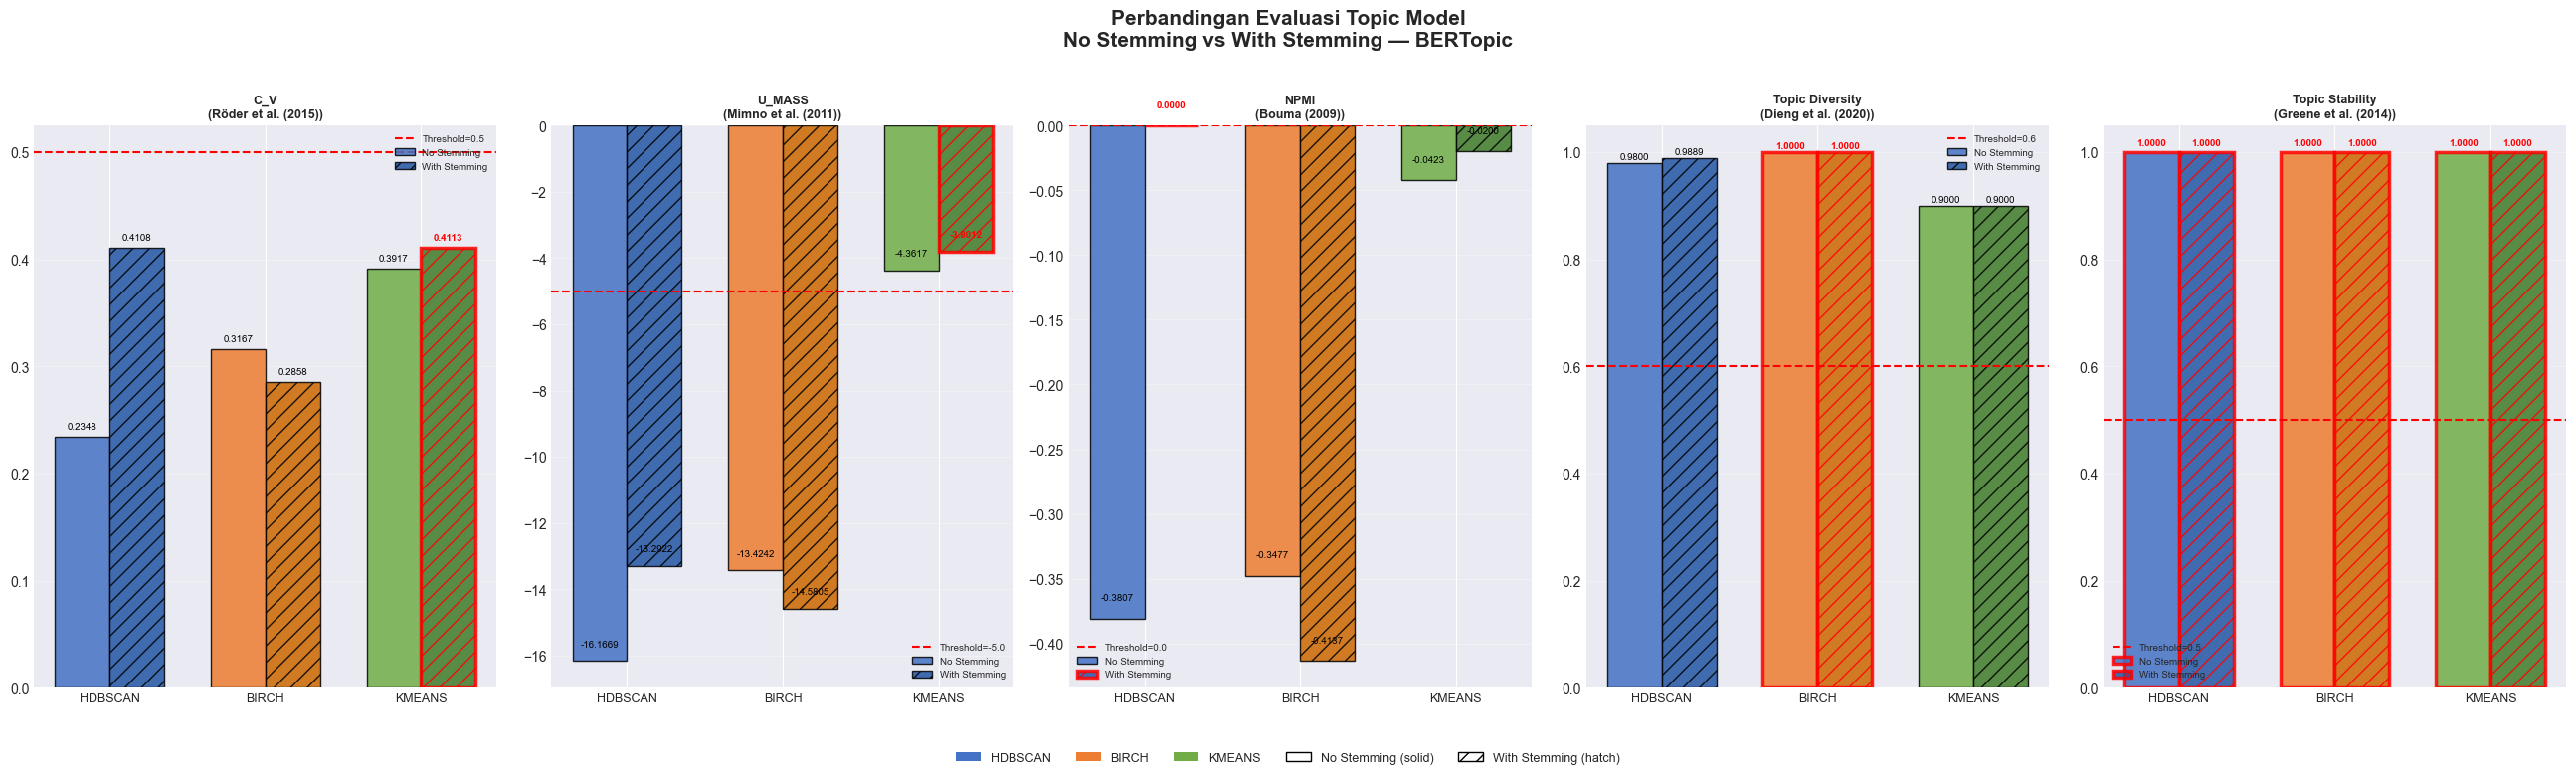

✓ Disimpan: comparison_stem_vs_nostem.png


In [28]:
# ================================================================
# VISUALISASI PERBANDINGAN
# ================================================================
metrics_compare = [
    ('c_v',       'C_V',             0.5,   True,
     'Röder et al. (2015)'),
    ('u_mass',    'U_MASS',          -5.0,  True,
     'Mimno et al. (2011)'),
    ('npmi',      'NPMI',            0.0,   True,
     'Bouma (2009)'),
    ('diversity', 'Topic Diversity', 0.6,   True,
     'Dieng et al. (2020)'),
    ('stability', 'Topic Stability', 0.5,   True,
     'Greene et al. (2014)'),
]

models      = ["HDBSCAN", "BIRCH", "KMEANS"]
x           = np.arange(len(models))
width       = 0.35

# Warna No Stemming (solid) & With Stemming (hatch)
colors_ns   = ['#4472C4', '#ED7D31', '#70AD47']
colors_s    = ['#2255A3', '#CC6600', '#3D7A28']

fig, axes = plt.subplots(1, 5, figsize=(26, 7))
fig.suptitle(
    'Perbandingan Evaluasi Topic Model\n'
    'No Stemming vs With Stemming — BERTopic',
    fontsize=15, fontweight='bold', y=1.02
)

for ax, (key, title, threshold, higher, ref) in \
        zip(axes, metrics_compare):

    vals_ns = [eval_results_no_stem[m][key]   for m in models]
    vals_s  = [eval_results_with_stem[m][key] for m in models]

    # Handle nan
    vals_ns = [v if v is not None and not
               (isinstance(v, float) and np.isnan(v))
               else 0.0 for v in vals_ns]
    vals_s  = [v if v is not None and not
               (isinstance(v, float) and np.isnan(v))
               else 0.0 for v in vals_s]

    bars1 = ax.bar(x - width/2, vals_ns, width,
                   color=colors_ns, edgecolor='black',
                   alpha=0.85, label='No Stemming')
    bars2 = ax.bar(x + width/2, vals_s,  width,
                   color=colors_s, edgecolor='black',
                   alpha=0.85, hatch='//',
                   label='With Stemming')

    # Garis threshold
    ax.axhline(threshold, color='red', linestyle='--',
               linewidth=1.5, label=f'Threshold={threshold}',
               zorder=5)

    # Highlight bar terbaik
    all_vals = vals_ns + vals_s
    if higher:
        best_val = max(all_vals)
    else:
        best_val = min(all_vals)

    # Nilai di atas bar
    for bar, val in zip(list(bars1) + list(bars2),
                        vals_ns + vals_s):
        is_best = (val == best_val)
        h       = bar.get_height()
        offset  = abs(max(all_vals) - min(all_vals)) * 0.03 \
                  if max(all_vals) != min(all_vals) else 0.01
        ax.text(
            bar.get_x() + bar.get_width()/2.,
            h + offset,
            f'{val:.4f}',
            ha='center', va='bottom',
            fontsize=7,
            fontweight='bold' if is_best else 'normal',
            color='red' if is_best else 'black'
        )
        if is_best:
            bar.set_edgecolor('red')
            bar.set_linewidth(2.5)

    ax.set_title(f'{title}\n({ref})',
                 fontweight='bold', fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=9)
    ax.legend(fontsize=7, loc='best')
    ax.grid(axis='y', alpha=0.3)

# Legend utama
legend_elements = [
    mpatches.Patch(facecolor='#4472C4', label='HDBSCAN'),
    mpatches.Patch(facecolor='#ED7D31', label='BIRCH'),
    mpatches.Patch(facecolor='#70AD47', label='KMEANS'),
    mpatches.Patch(facecolor='white', edgecolor='black',
                   label='No Stemming (solid)'),
    mpatches.Patch(facecolor='white', edgecolor='black',
                   hatch='//', label='With Stemming (hatch)'),
]
fig.legend(handles=legend_elements,
           loc='lower center', ncol=5,
           fontsize=9, bbox_to_anchor=(0.5, -0.08))

plt.tight_layout()
plt.savefig('comparison_stem_vs_nostem.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("✓ Disimpan: comparison_stem_vs_nostem.png")